# Beam Quality Cut

In [24]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
from os import path, makedirs
from datetime import datetime
from functools import partial

import numpy as np
import pandas as pd

import sys
# sys.path.append('../../../')
sys.path.append('/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana') # absolute path for running on EAF
from pyanalib.split_df_helpers import *
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from analysis_village.numucc_1p0pi.utils import *
from analysis_village.numucc_1p0pi.files_config import *
plt.style.use("presentation.mplstyle")

In [26]:
save_fig = True

today_str = datetime.now().strftime("%Y%m%d")
save_fig_dir = path.join(save_fig_base_dir, "beam_quality")

if save_fig:
    if not path.exists(save_fig_dir):
        makedirs(save_fig_dir)
    print("saving plots in ", save_fig_dir)

saving plots in  /exp/sbnd/data/users/munjung/plots/numucc1p0pi/beam_quality


In [27]:
# data_file = "/exp/sbnd/data/users/munjung/xsec/2025Spring_v10_06_00_09/data/BNB/Gen1_mup.df"
# data_dfs = load_dfs(data_file, 
#                     ['evt', 'hdr', 'bnbpot', 'trigger'], 
#                     n_max_concat=n_max_concat)
# data_evt_df_ = data_dfs['evt']
# data_hdr_df_ = data_dfs['hdr']

In [28]:
df_dir = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_01_102310__sel_mup-data-BNB_cosmics"
from pyanalib.split_df_helpers_new import *

keys2load_data = ['hdr', 'evt', 'bnbpot', 'trigger']
df_data = dfs_from_dir(search_dir=df_dir, filename_str="sel_mup-data-BNB_cosmics", keys2load=keys2load_data, n_max_concat=999)

Found 50 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_01_102310__sel_mup-data-BNB_cosmics/sel_mup-data-BNB_cosmics_0.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_01_102310__sel_mup-data-BNB_cosmics/sel_mup-data-BNB_cosmics_1.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_01_102310__sel_mup-data-BNB_cosmics/sel_mup-data-BNB_cosmics_10.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_01_102310__sel_mup-data-BNB_cosmics/sel_mup-data-BNB_cosmics_11.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_01_102310__sel_mup-data-BNB_cosmics/sel_mup-data-BNB_cosmics_12.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_01_102310__sel_mup-data-BNB_cosmics/sel_mup-data-BNB_cosmics_13.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_01_102310__sel_mup-data-BNB_cosmics/sel_mup-data-BNB_cosmics_14.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_01

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [01:15<00:00,  1.51s/it]


In [29]:
data_evt_df_ = df_data['evt']
pot_df = df_data['bnbpot']
data_hdr_df_ = df_data['hdr']
trigger_df = df_data['trigger']
data_hdr_df_ = data_hdr_df_.join(trigger_df)

In [30]:
np.isnan(data_hdr_df_.global_trigger_time).sum()
np.isnan(data_hdr_df_.beam_gate_time_abs).sum()

np.int64(0)

In [31]:
# split data into 15 time-ordered chunks

n_time_splits = 15
chunk_idx = 0

data_evt_df_["mc", "iscc"] = 999

_sorted = data_hdr_df_.sort_values(["run", "evt"], kind="mergesort")
data_hdr_df_splits = [
    _sorted.iloc[idx]
    for idx in np.array_split(np.arange(len(_sorted)), n_time_splits)
]
for i in range(n_time_splits):
    data_hdr_df = data_hdr_df_splits[i]

data_hdr_df = data_hdr_df_splits[chunk_idx]
evt_idxs = data_evt_df_.index
common_idxs = data_evt_df_.reset_index(level=[2]).index.intersection(data_hdr_df.index)
data_evt_df = data_evt_df_.reset_index(level=[2]).loc[common_idxs].reset_index().set_index(["__ntuple", "entry", "rec.slc..index"])

/tmp/ipykernel_1129838/1859459668.py:6: PerformanceWarning: indexing past lexsort depth may impact performance.
  data_evt_df_["mc", "iscc"] = 999


In [50]:
# --- Task 1: Time window per chunk ---
# global_trigger_time is in nanoseconds
chunk_summary = []
for i, chunk_df in enumerate(data_hdr_df_splits):
    t_min = chunk_df['global_trigger_time'].min()
    t_max = chunk_df['global_trigger_time'].max()
    chunk_summary.append({
        'Chunk': i,
        'Events': len(chunk_df),
        'Start Time (UTC)': pd.Timestamp(t_min, unit='ns', tz='UTC').strftime('%Y-%m-%d %H:%M:%S %Z'),
        'End Time (UTC)': pd.Timestamp(t_max, unit='ns', tz='UTC').strftime('%Y-%m-%d %H:%M:%S %Z'),
        'Duration (min)': round((t_max - t_min) / 60e9, 1),
    })

chunk_time_df = pd.DataFrame(chunk_summary).set_index('Chunk')
chunk_time_df

,Events,Start Time (UTC),End Time (UTC),Duration (min)
Chunk,,,,
0,110509,2025-02-13 21:11:24 UTC,2025-02-20 02:34:29 UTC,8963.1
1,110509,2025-02-20 02:34:30 UTC,2025-02-23 02:10:19 UTC,4295.8
2,110509,2025-02-23 02:10:20 UTC,2025-02-26 03:59:50 UTC,4429.5
3,110509,2025-02-26 03:59:51 UTC,2025-03-01 05:44:40 UTC,4424.8
4,110508,2025-03-01 05:44:41 UTC,2025-03-04 08:21:12 UTC,4476.5
5,110508,2025-03-04 08:21:18 UTC,2025-03-08 21:25:30 UTC,6544.2
6,110508,2025-03-08 21:25:44 UTC,2025-03-13 03:32:52 UTC,6127.1
7,110508,2025-03-13 03:32:54 UTC,2025-03-16 17:23:47 UTC,5150.9
8,110508,2025-03-16 17:23:48 UTC,2025-03-21 06:32:25 UTC,6548.6


In [33]:
# --- Task 2: Match each triggered event to its beam spill ---
# Strategy: for each trigger, find the latest beam spill (within the same ntuple)
# whose start time is <= trigger_time.  Uses numpy searchsorted per ntuple so
# there are no merge_asof edge-cases (NaN keys, absent ntuples, etc.).
#
# If a trigger's ntuple has no entries in pot_df at all, fall back to the
# nearest spill across *all* ntuples.
#
# Assignment is done positionally (via .values) to avoid pandas index-alignment
# NaN issues that arise when data_hdr_df_ has duplicate (__ntuple, entry) pairs.

pot_reset = pot_df.reset_index()
pot_reset['spill_time'] = pot_reset['spill_time_sec'] + pot_reset['spill_time_nsec'] * 1e-9

hdr_reset = data_hdr_df_.reset_index()[['__ntuple', 'entry', 'evt', 'global_trigger_time']]
hdr_reset['trigger_time_s'] = hdr_reset['global_trigger_time'] * 1e-9  # ns -> s
hdr_reset['_orig_idx'] = np.arange(len(hdr_reset))  # preserve row order for positional assignment

beam_cols = ['TOR875', 'TOR860', 'FOM', 'THCURR', 'spill_time']

# Build a per-ntuple lookup table (sorted by spill_time for searchsorted)
pot_by_ntuple = {
    ntuple: grp.sort_values('spill_time').reset_index(drop=True)
    for ntuple, grp in pot_reset.groupby('__ntuple')
}
# Global fallback (for ntuples entirely absent from pot_df)
all_spills = pot_reset.sort_values('spill_time').reset_index(drop=True)

results = []
n_global_fallback = 0
fallback_rows = []  # collect fallback events for printing

for ntuple, hdr_grp in hdr_reset.groupby('__ntuple'):
    spills = pot_by_ntuple.get(ntuple)
    if spills is None:
        # Ntuple absent from pot_df: use globally nearest spill
        spills = all_spills
        n_global_fallback += len(hdr_grp)
        fallback_rows.append(hdr_grp[['__ntuple', 'entry', 'evt', 'trigger_time_s']])

    times = spills['spill_time'].values
    trigger_times = hdr_grp['trigger_time_s'].values

    # searchsorted gives the insertion point; -1 gives the index of the
    # latest spill whose start is at or before the trigger time.
    # clip ensures we never go out of bounds (handles triggers before the
    # first spill or after the last spill).
    idx = np.searchsorted(times, trigger_times, side='right') - 1
    idx = np.clip(idx, 0, len(spills) - 1)

    matched_spills = spills.iloc[idx][beam_cols].reset_index(drop=True)
    result = hdr_grp[['_orig_idx']].reset_index(drop=True)
    result = pd.concat([result, matched_spills], axis=1)
    results.append(result)

# Sort back to original row order and assign positionally — avoids all
# index-alignment issues (e.g. duplicate (__ntuple, entry) pairs).
matched_ordered = pd.concat(results, ignore_index=True).sort_values('_orig_idx')

for col in beam_cols:
    data_hdr_df_[col] = matched_ordered[col].values

n_matched = data_hdr_df_['TOR875'].notna().sum()
n_total   = len(data_hdr_df_)

if n_global_fallback:
    print(f"  {n_global_fallback} event(s) had no pot_df entry for their ntuple "
          f"— matched to nearest global spill instead.")
    fallback_df = pd.concat(fallback_rows, ignore_index=True)
    print(fallback_df.to_string(index=False))
print(f"Matched {n_matched} / {n_total} events to a beam spill.")

# --- Diagnostic: print any events that are still unmatched ---
failures = data_hdr_df_[data_hdr_df_['TOR875'].isna()]
if len(failures) > 0:
    print(f"\n=== {len(failures)} UNMATCHED EVENT(S) ===")
    print(failures.reset_index()[['__ntuple', 'entry', 'evt', 'global_trigger_time']].to_string())
    print(f"\ndata_hdr_df_.index.is_unique : {data_hdr_df_.index.is_unique}")
    print(f"matched_ordered has {len(matched_ordered)} rows for {n_total} events")
else:
    print("All events matched successfully.")

data_hdr_df_[['evt', 'global_trigger_time', 'TOR875', 'TOR860', 'FOM', 'THCURR', 'spill_time']].head(20)

  2 event(s) had no pot_df entry for their ntuple — matched to nearest global spill instead.
 __ntuple  entry  evt  trigger_time_s
    18226      0   46    1.741386e+09
    19874      0   31    1.744212e+09
Matched 1657624 / 1657624 events to a beam spill.
All events matched successfully.


evt  global_trigger_time        TOR875        TOR860  \
__ntuple entry                                                            
4        0      395151  1742771180318996860  4.985356e+12  4.965307e+12   
         1      395283  1742771219322687840  4.995437e+12  4.966573e+12   
         2      395305  1742771226320439040  4.986790e+12  4.956767e+12   
         3      395371  1742771245179235380  4.971442e+12  4.959045e+12   
         4      395503  1742771283107566200  5.035494e+12  4.986846e+12   
         5      395613  1742771313247176440  4.979621e+12  4.936442e+12   
         6      395811  1742771372246383920  4.996349e+12  4.948007e+12   
         7      395943  1742771406107226620  4.984418e+12  4.965644e+12   
         8      396229  1742771493328552000  5.004191e+12  4.964145e+12   
         9      396273  1742771506331523840  5.015255e+12  4.983420e+12   
         10     396471  1742771563270726700  4.999308e+12  4.968511e+12   
         11     396581  1742771594081428260  4.933826e+12  4.914463e+12   
         12     396933  1742771696228188760  4.940736e+12  4.935667e+12   
         13     396999  1742771715167358380  4.974553e+12  4.964998e+12   
         14     397043  1742771728169905940  4.980239e+12  4.942909e+12   
         15     397307  1742771804404441880  4.919800e+12  4.897289e+12   
         16     397329  1742771811207512740  4.957137e+12  4.917665e+12   
         17     397395  1742771830348645320  4.955328e+12  4.921790e+12   
         18     397417  1742771837417911420  5.000759e+12  4.969325e+12   
         19     397527  1742771866157703880  4.949525e+12  4.921584e+12   

                     FOM      THCURR    spill_time  
__ntuple entry                                      
4        0      0.999876  173.769531  1.742771e+09  
         1      0.999823  173.779297  1.742771e+09  
         2      0.999856  173.798828  1.742771e+09  
         3      0.999880  173.818359  1.742771e+09  
         4      0.999854  173.759766  1.742771e+09  
         5      0.999880  173.662109  1.742771e+09  
         6      0.999910  173.798828  1.742771e+09  
         7      0.999887  173.789062  1.742771e+09  
         8      0.999871  173.789062  1.742771e+09  
         9      0.999855  173.779297  1.742772e+09  
         10     0.999920  173.759766  1.742772e+09  
         11     0.999744  173.154297  1.742772e+09  
         12     0.999749  173.789062  1.742772e+09  
         13     0.999813  173.740234  1.742772e+09  
         14     0.999844  173.789062  1.742772e+09  
         15     0.999855  173.769531  1.742772e+09  
         16     0.999901  173.769531  1.742772e+09  
         17     0.999835  173.769531  1.742772e+09  
         18     0.999880  173.798828  1.742772e+09  
         19     0.999853  173.349609  1.742772e+09

In [34]:
# pot_df.loc[18226]
# data_hdr_df_.loc[18226]

In [35]:
# 645084      18226   46    1.741386e+09
# 1617671     19874   31    1.744212e+09

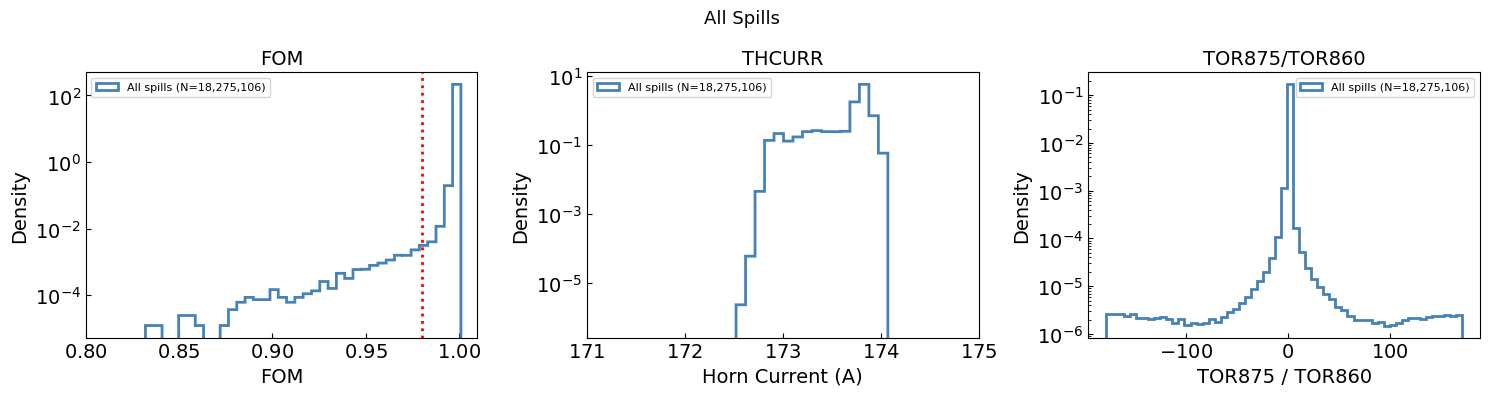

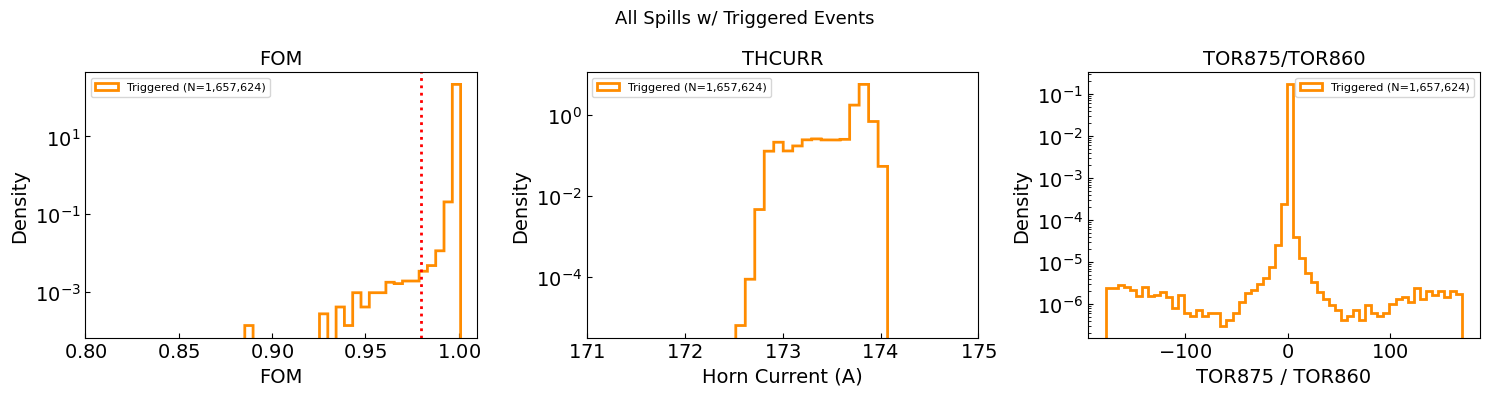

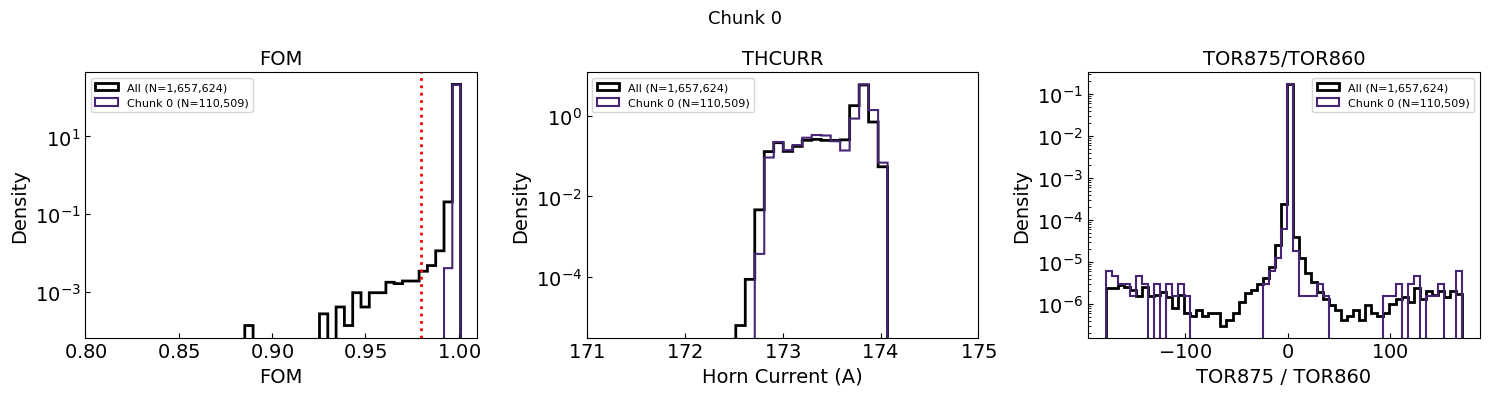

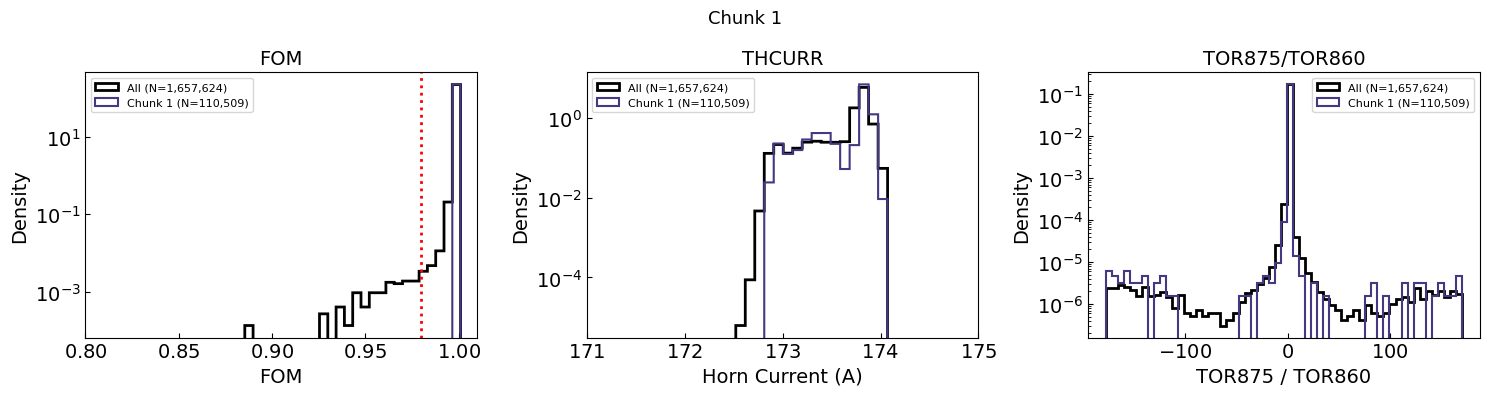

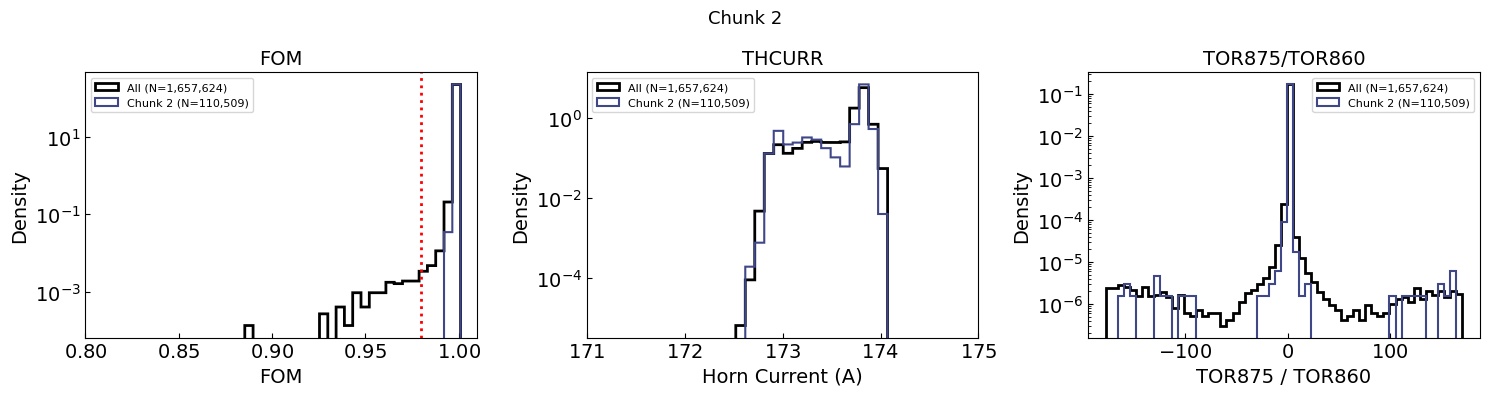

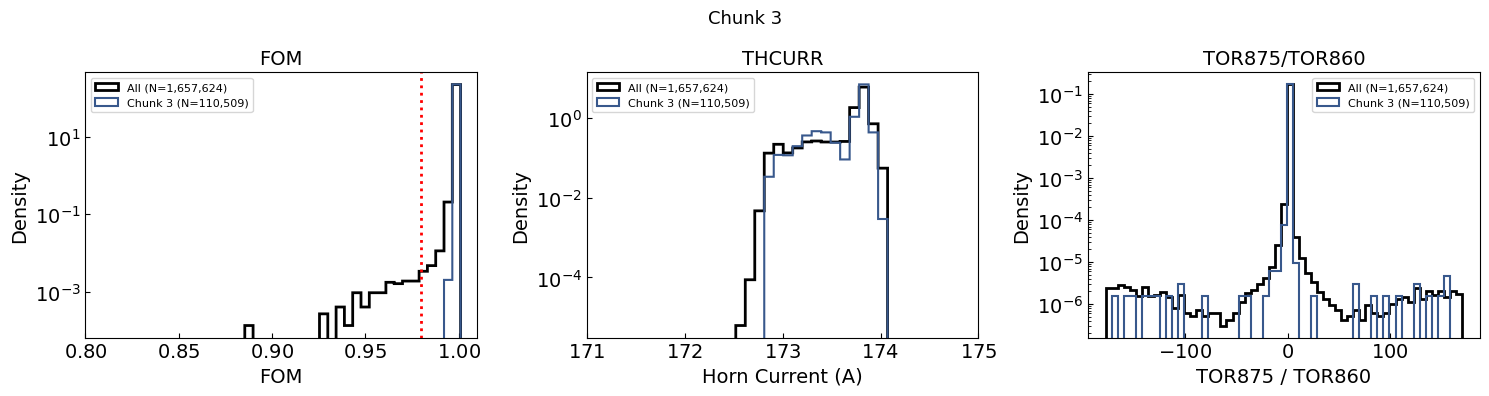

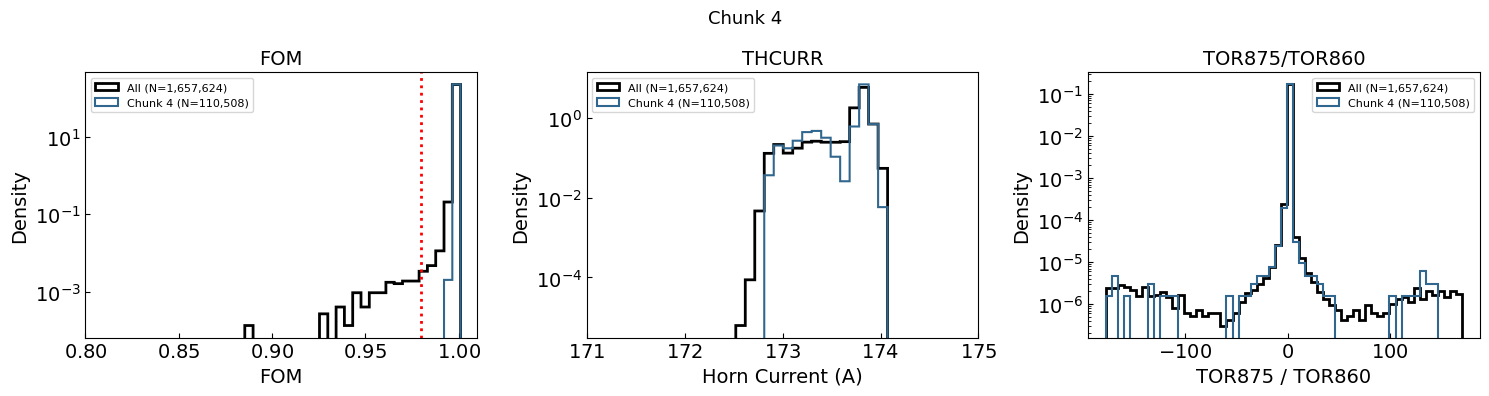

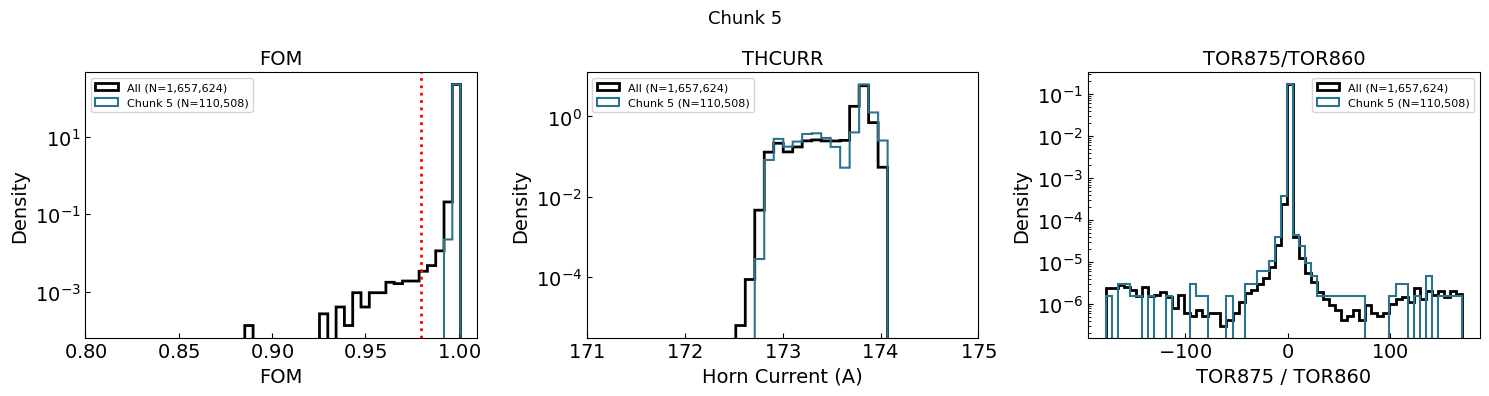

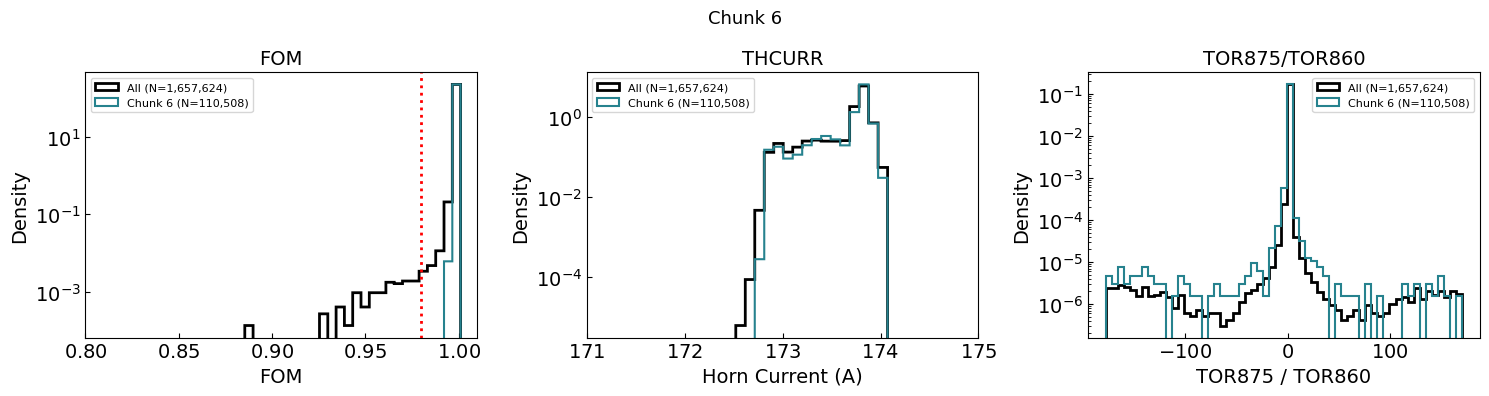

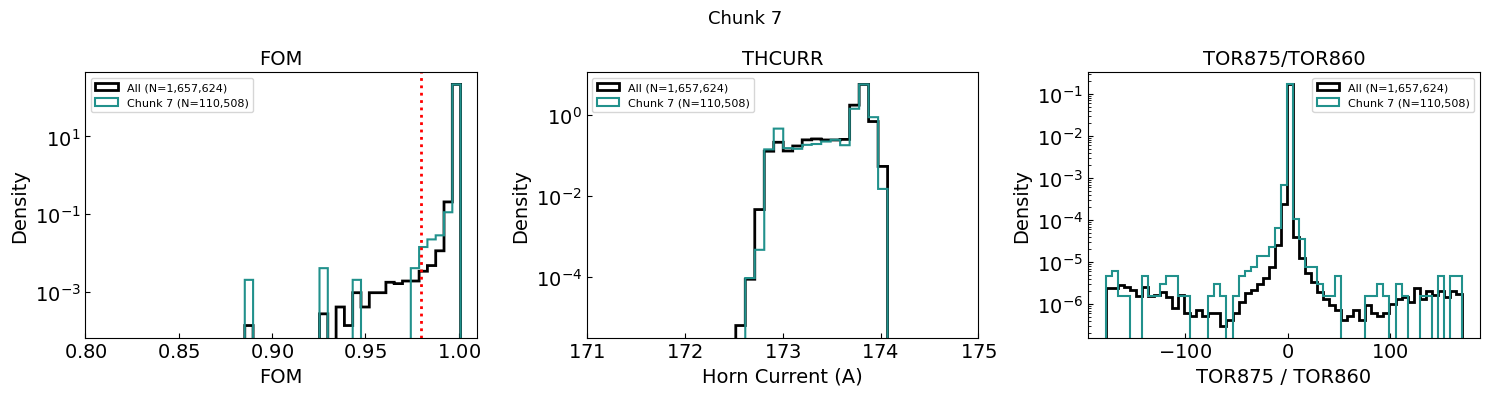

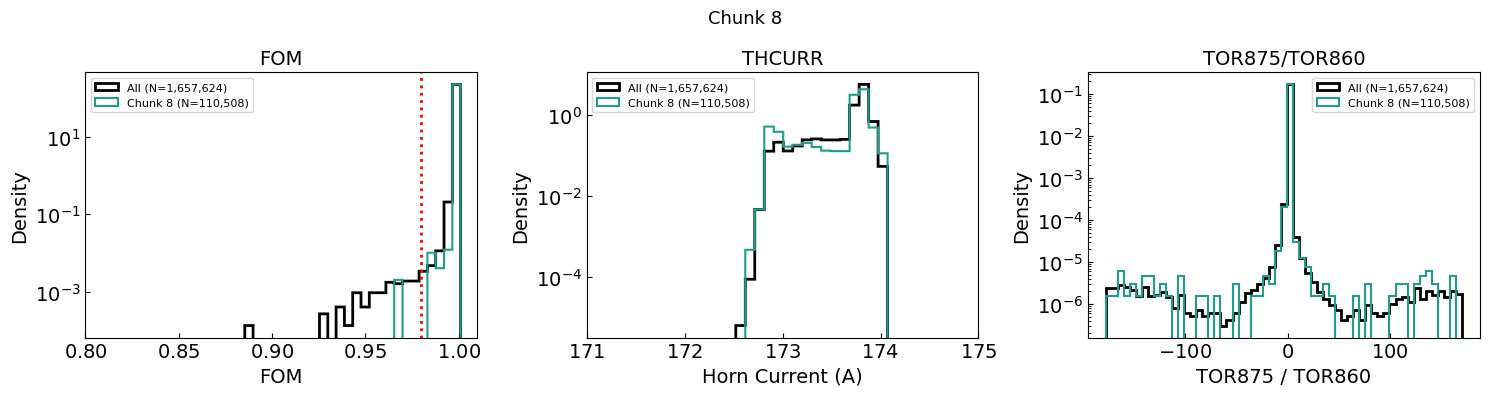

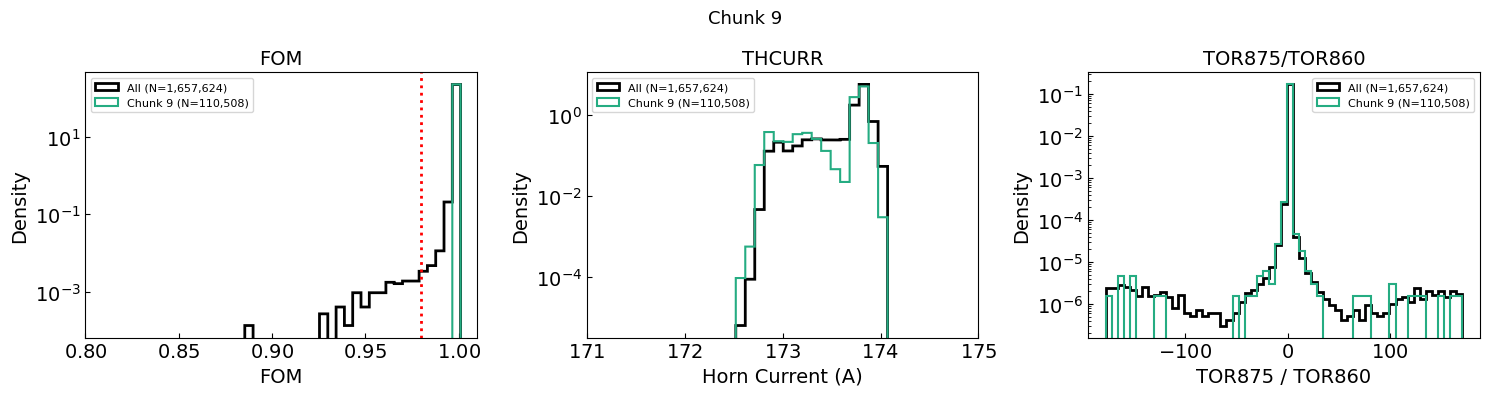

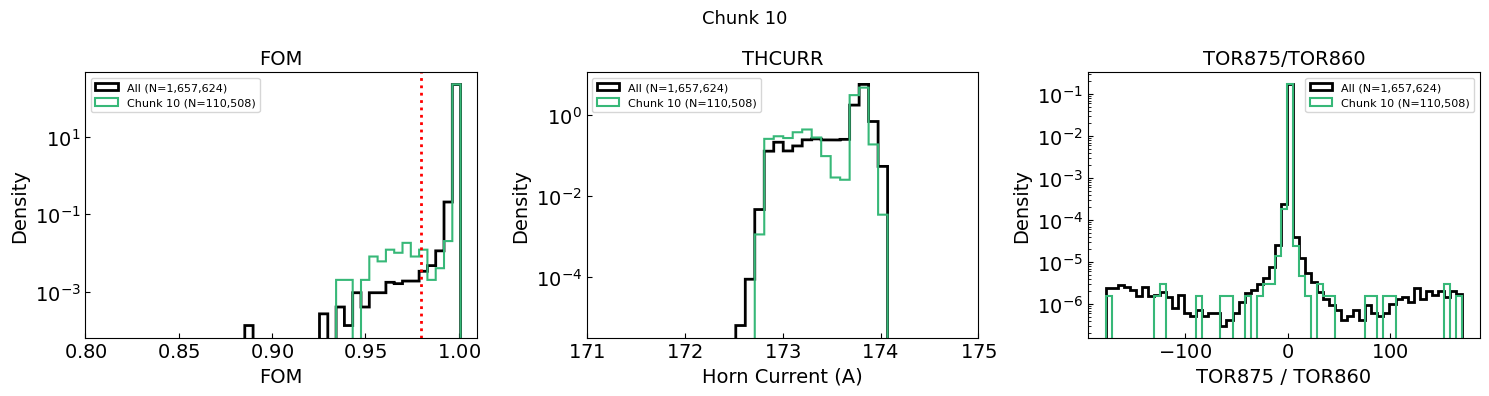

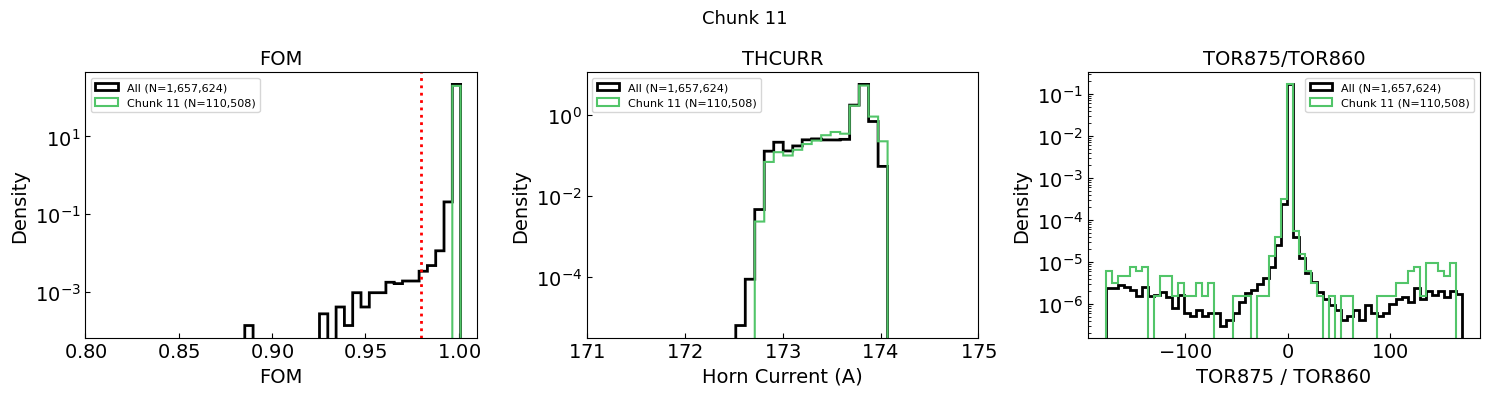

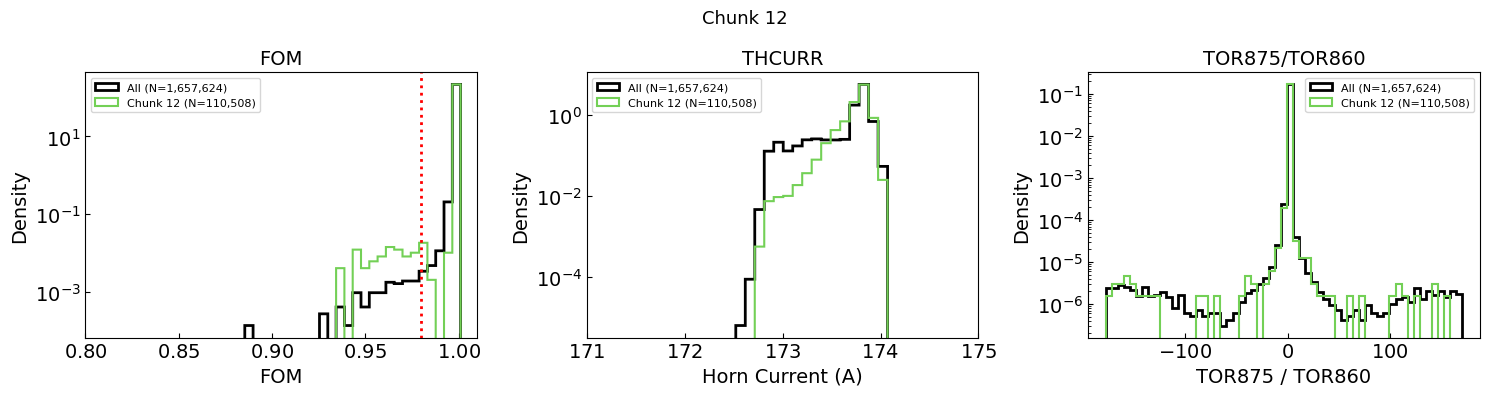

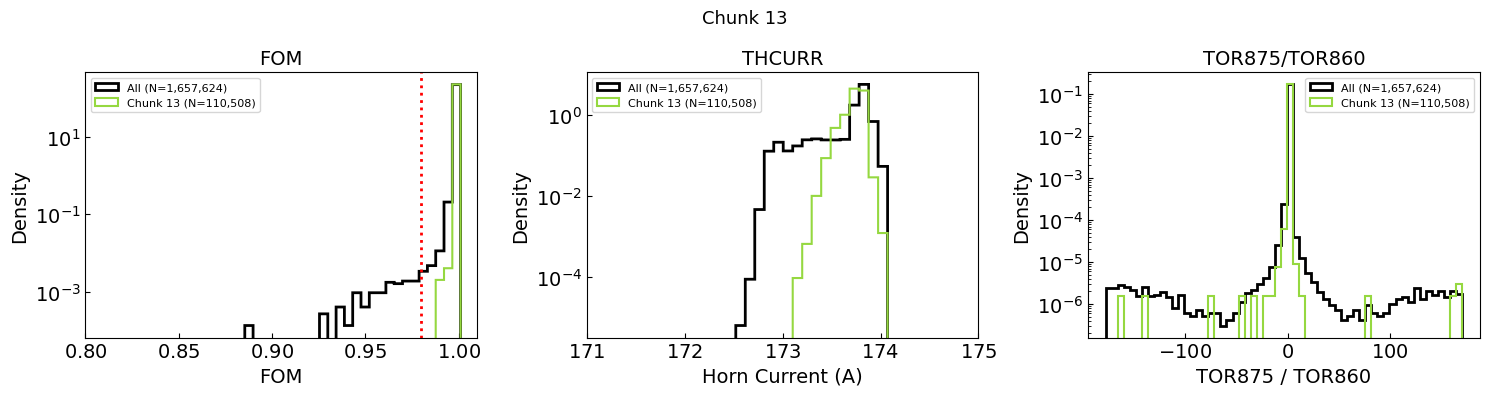

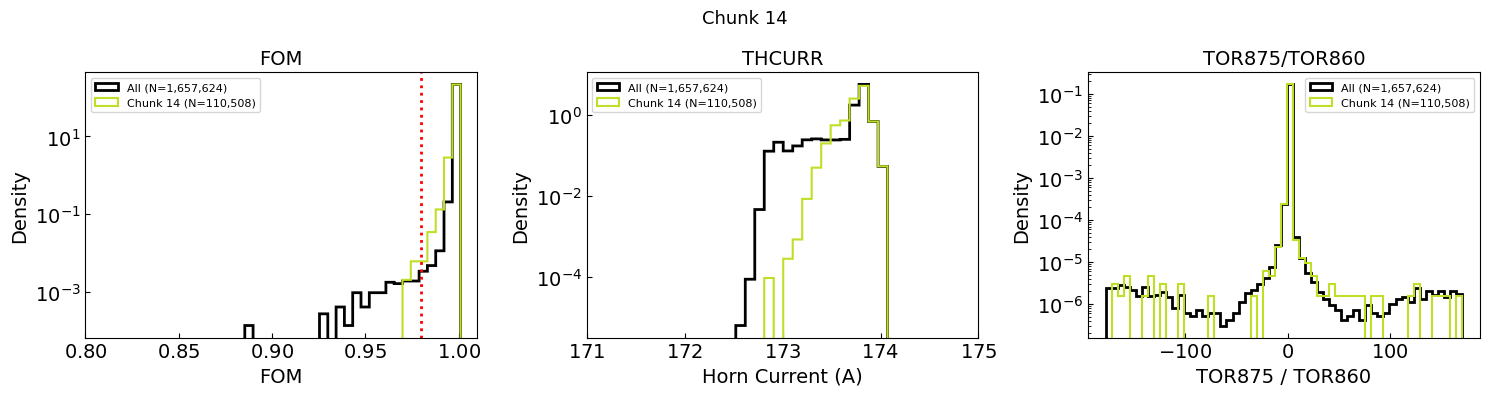

In [47]:
# --- Beam quality metrics ---
# Re-split data_hdr_df_ (now includes matched beam columns) into time chunks
_sorted_beam = data_hdr_df_.sort_values(["run", "evt"], kind="mergesort")
hdr_splits_beam = [
    _sorted_beam.iloc[idx]
    for idx in np.array_split(np.arange(len(_sorted_beam)), n_time_splits)
]

pot_reset = pot_df.reset_index().copy()
pot_reset['TOR_ratio'] = pot_reset['TOR875'] / pot_reset['TOR860']

hdr_all = data_hdr_df_[['TOR875', 'TOR860', 'FOM', 'THCURR']].dropna().copy()
hdr_all['TOR_ratio'] = hdr_all['TOR875'] / hdr_all['TOR860']

metrics = [
    ('FOM',       r'FOM',           r'FOM'),
    ('THCURR',    r'THCURR',        r'Horn Current (A)'),
    ('TOR_ratio', r'TOR875/TOR860', r'TOR875 / TOR860'),
]

def get_vals(df, col):
    if col == 'TOR_ratio':
        return (df['TOR875'] / df['TOR860']).replace([np.inf, -np.inf], np.nan).dropna()
    return df[col].replace([np.inf, -np.inf], np.nan).dropna()

xlim_dict = {
    'FOM':       (0.8,  1.01),
    'THCURR':    (171,  175),
    'TOR_ratio': None,          # no restriction — use full range
}

def make_beam_fig(title, datasets, bins_dict, save_suffix=None):
    """datasets: list of (label, color, linewidth, vals_dict {col: series})"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, (col, label, xlabel) in zip(axes, metrics):
        bins = bins_dict[col]
        for ds_label, color, lw, vals_dict in datasets:
            vals = vals_dict[col]
            if len(vals) == 0:
                continue
            ax.hist(vals, bins=bins, density=True, histtype='step',
                    linewidth=lw, color=color, label=f'{ds_label} (N={len(vals):,})')
        ax.set_yscale('log')
        ax.set_xlabel(xlabel)
        ax.set_ylabel('Density')
        ax.set_title(label)
        ax.legend(fontsize=8)
        if col == 'FOM':
            ax.axvline(0.98, color='red', linestyle=':', linewidth=2)
        if xlim_dict.get(col) is not None:
            ax.set_xlim(xlim_dict[col])
    fig.suptitle(title, fontsize=13)
    fig.tight_layout()
    if save_fig and save_suffix:
        fig.savefig(path.join(save_fig_dir, f"{today_str}_beam_{save_suffix}.png"), dpi=300, bbox_inches='tight')
    plt.show()

# Build shared bins from the global all-spills distribution
# Use 15x more bins for FOM and THCURR (zoomed metrics).
bins_dict = {}
base_nbins = 60
nbins_dict = {
    'FOM': base_nbins * 15,
    'THCURR': base_nbins * 30,
    'TOR_ratio': base_nbins,
}
for col, _, _ in metrics:
    vals = get_vals(pot_reset, col)
    nbins = nbins_dict.get(col, base_nbins)
    bins_dict[col] = np.linspace(vals.quantile(0.001), vals.quantile(0.999), nbins)

# --- Figure 1: All spills (pot_df) ---
all_spills_data = {col: get_vals(pot_reset, col) for col, _, _ in metrics}
make_beam_fig(
    title='All Spills ',
    datasets=[('All spills', 'steelblue', 2, all_spills_data)],
    bins_dict=bins_dict,
    save_suffix='all_spills',
)

# --- Figure 2: All triggered spills (data_hdr_df_) ---
triggered_data = {col: get_vals(hdr_all, col) for col, _, _ in metrics}
make_beam_fig(
    title='All Spills w/ Triggered Events',
    datasets=[('Triggered', 'darkorange', 2, triggered_data)],
    bins_dict=bins_dict,
    save_suffix='all_triggered',
)

# --- Figure per chunk: all triggered spills vs. chunk triggered ---
chunk_colors = plt.cm.viridis(np.linspace(0.1, 0.9, n_time_splits))
for i, chunk_df in enumerate(hdr_splits_beam):
    chunk_data = {col: get_vals(chunk_df, col) for col, _, _ in metrics}
    make_beam_fig(
        title=f'Chunk {i}',
        datasets=[
            ('All', 'black',         2,   triggered_data),
            (f'Chunk {i}',    chunk_colors[i], 1.5, chunk_data)
        ],
        bins_dict=bins_dict,
        save_suffix=f'chunk_{i:02d}',
    )

In [51]:
# --- Extended time-window table with beam quality failure statistics (per chunk) ---
# Uses hdr_splits_beam from the plotting cell (matched FOM per triggered event)
beam_stats = []
for i, chunk_df in enumerate(hdr_splits_beam):
    fom = chunk_df['FOM'].dropna()
    n_total = len(fom)
    n_failures = int((fom == 0).sum() + (fom == 4).sum())   # FOM == 0 or FOM == 4
    n_bad      = int(((fom < 0.98) & (fom > 0)).sum())                     # FOM < 0.98 (includes failures)
    beam_stats.append({
        'Chunk': i,
        'Failures % (FOM=0|4)':   round(100 * n_failures / n_total, 2) if n_total > 0 else float('nan'),
        'Bad Spills % (FOM<0.98)': round(100 * n_bad      / n_total, 2) if n_total > 0 else float('nan'),
    })

beam_stats_df = pd.DataFrame(beam_stats).set_index('Chunk')
chunk_time_extended_df = chunk_time_df.drop(columns=['Duration (min)']).join(beam_stats_df)
display(chunk_time_extended_df)

# --- LaTeX table output ---
latex_df = chunk_time_extended_df.copy()
latex_df.index.name = 'Chunk'
latex_str = latex_df.to_latex(
    float_format='%.2f',
    caption='Time window and beam quality summary per data chunk.',
    label='tab:beam_quality_chunks',
    column_format='c' * 6,
)
print(latex_str)

,Events,Start Time (UTC),End Time (UTC),Failures % (FOM=0|4),Bad Spills % (FOM<0.98)
Chunk,,,,,
0,110509,2025-02-13 21:11:24 UTC,2025-02-20 02:34:29 UTC,3.87,0.00
1,110509,2025-02-20 02:34:30 UTC,2025-02-23 02:10:19 UTC,1.05,0.00
2,110509,2025-02-23 02:10:20 UTC,2025-02-26 03:59:50 UTC,1.39,0.00
3,110509,2025-02-26 03:59:51 UTC,2025-03-01 05:44:40 UTC,1.00,0.00
4,110508,2025-03-01 05:44:41 UTC,2025-03-04 08:21:12 UTC,1.32,0.00
5,110508,2025-03-04 08:21:18 UTC,2025-03-08 21:25:30 UTC,1.85,0.00
6,110508,2025-03-08 21:25:44 UTC,2025-03-13 03:32:52 UTC,2.14,0.00
7,110508,2025-03-13 03:32:54 UTC,2025-03-16 17:23:47 UTC,2.40,0.01
8,110508,2025-03-16 17:23:48 UTC,2025-03-21 06:32:25 UTC,1.32,0.00


\begin{table}
\caption{Time window and beam quality summary per data chunk.}
\label{tab:beam_quality_chunks}
\begin{tabular}{cccccc}
\toprule
 & Events & Start Time (UTC) & End Time (UTC) & Failures % (FOM=0|4) & Bad Spills % (FOM<0.98) \\
Chunk &  &  &  &  &  \\
\midrule
0 & 110509 & 2025-02-13 21:11:24 UTC & 2025-02-20 02:34:29 UTC & 3.87 & 0.00 \\
1 & 110509 & 2025-02-20 02:34:30 UTC & 2025-02-23 02:10:19 UTC & 1.05 & 0.00 \\
2 & 110509 & 2025-02-23 02:10:20 UTC & 2025-02-26 03:59:50 UTC & 1.39 & 0.00 \\
3 & 110509 & 2025-02-26 03:59:51 UTC & 2025-03-01 05:44:40 UTC & 1.00 & 0.00 \\
4 & 110508 & 2025-03-01 05:44:41 UTC & 2025-03-04 08:21:12 UTC & 1.32 & 0.00 \\
5 & 110508 & 2025-03-04 08:21:18 UTC & 2025-03-08 21:25:30 UTC & 1.85 & 0.00 \\
6 & 110508 & 2025-03-08 21:25:44 UTC & 2025-03-13 03:32:52 UTC & 2.14 & 0.00 \\
7 & 110508 & 2025-03-13 03:32:54 UTC & 2025-03-16 17:23:47 UTC & 2.40 & 0.01 \\
8 & 110508 & 2025-03-16 17:23:48 UTC & 2025-03-21 06:32:25 UTC & 1.32 & 0.00 \\
9 & 110

In [38]:
hdr_splits_beam[-1]

,,pot,nbnbinfo,first_in_subrun,ismc,run,subrun,ngenevt,evt,proc,cluster,...,prev_global_trigger_time,global_trigger_det_time,trigger_within_gate,beam_gate_det_time,beam_gate_time_abs,TOR875,TOR860,FOM,THCURR,spill_time
__ntuple,entry,,,,,,,,,,,,,,,,,,,,,
12720,25,0.0,0,0,0,18390,1,0,809472,0,67610002,...,0,NaN,NaN,NaN,1743992250063345600,4.960525e+12,4.943303e+12,0.999949,173.769531,1.743992e+09
458,10,0.0,0,0,0,18390,1,0,809479,0,67610108,...,0,NaN,NaN,NaN,1743992251796692140,4.953417e+12,4.936777e+12,0.999963,173.632812,1.743992e+09
30093,48,0.0,0,0,0,18390,1,0,809498,0,25456113,...,0,NaN,NaN,NaN,1743992257863353600,5.020063e+12,5.034665e+12,0.999953,173.759766,1.743992e+09
12568,13,0.0,0,0,0,18390,1,0,809506,0,67609039,...,0,NaN,NaN,NaN,1743992260796549420,4.976185e+12,4.985912e+12,0.999961,173.515625,1.743992e+09
20668,32,0.0,0,0,0,18390,1,0,809510,0,25455670,...,0,NaN,NaN,NaN,1743992261863141700,4.948833e+12,4.925866e+12,0.999953,173.750000,1.743992e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28743,32,0.0,0,0,0,18412,1,0,332640,0,67621180,...,0,NaN,NaN,NaN,1744310171170716900,-1.305448e+10,-1.086511e+10,4.000000,-0.146484,1.744310e+09
4932,3,0.0,0,0,0,18412,1,0,332657,0,67616019,...,0,NaN,NaN,NaN,1744310176235798100,-2.637421e+10,-1.508592e+09,4.000000,-0.126953,1.744310e+09
27516,43,0.0,0,0,0,18412,1,0,332719,0,67622000,...,0,NaN,NaN,NaN,1744310197093655600,-1.788864e+10,-1.903033e+09,4.000000,-0.214844,1.744310e+09
